<a href="https://colab.research.google.com/github/DD-Bin/Dede-Bintang-Gafendi_2411533010_ML2526/blob/main/Praktikum1/CaliforniaHousin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import load_diabetes
housing = load_diabetes()

df = pd.DataFrame(data= housing.data, columns=housing.feature_names)
df ['target'] = pd.Series(housing.target)

targets=df ['target']
input= df.drop ('target', axis=1)
df.tail()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
441,-0.045472,-0.044642,-0.073030,-0.081413,0.083740,0.027809,0.173816,-0.039493,-0.004222,0.003064,57.0


In [ ]:

from sklearn.preprocessing import MinMaxScaler
x_train, x_test, y_train, y_test = train_test_split(input, targets, test_size=0.3, random_state = 1)
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)
print(x_test)

(309, 10) (133, 10)
(309,) (133,)
          age       sex       bmi        bp        s1        s2        s3  \
246  0.041708 -0.044642 -0.032073 -0.061892  0.079612  0.050982  0.056003   
425 -0.078165 -0.044642 -0.040696 -0.081413 -0.100638 -0.112795  0.022869   
293 -0.070900 -0.044642  0.092953  0.012680  0.020446  0.042527  0.000779   
31  -0.023677 -0.044642 -0.065486 -0.081413 -0.038720 -0.053610  0.059685   
359  0.038076  0.050680  0.005650  0.032201  0.006687  0.017475 -0.024993   
..        ...       ...       ...       ...       ...       ...       ...   
340 -0.016412 -0.044642 -0.013751  0.132044 -0.009825 -0.003819  0.019187   
39  -0.001882  0.050680  0.014272 -0.074527  0.002559  0.006202 -0.013948   
191 -0.005515  0.050680 -0.041774 -0.043542 -0.079998 -0.076156 -0.032356   
320 -0.023677 -0.044642  0.030440 -0.005670  0.082364  0.092004 -0.017629   
98   0.001751  0.050680 -0.005128 -0.012556 -0.015328 -0.013840  0.008142   

           s4        s5        s6  
246 -

In [ ]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print(x_test)

[[0.68333333 0.         0.2231405  ... 0.2538787  0.65909649 0.28787879]
 [0.13333333 0.         0.19008264 ... 0.         0.40742041 0.31818182]
 [0.16666667 0.         0.70247934 ... 0.29337094 0.27554495 0.5       ]
 ...
 [0.46666667 1.         0.18595041 ... 0.14104372 0.52493945 0.46969697]
 [0.38333333 0.         0.46280992 ... 0.56417489 0.61279792 0.51515152]
 [0.5        1.         0.32644628 ... 0.14104372 0.46214328 0.25757576]]


In [ ]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

print(f'intercept: {lr_model.intercept_}')
print(f'slope: {lr_model.coef_}')

intercept: 2.7166561964967855
slope: [  -2.89974892  -22.69046851  151.8599737    78.16395165 -180.87959445
  107.16928533   25.23211365   56.93377687  172.58251035   12.60925097]


MSE: 2827.084017424083
R2: 0.43845439143447795


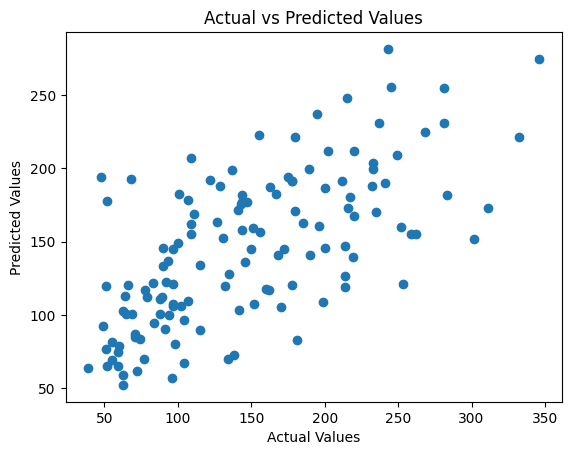

In [ ]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

y_pred=lr_model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=lr_model.score(x_test,y_test)
print(f'MSE: {mse}')
print(f'R2: {r2}')

plt.scatter(y_test,y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [ ]:
import pickle

filename = 'finalized_model.sav'
pickle.dump(lr_model, open(filename, 'wb'))

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

RMSE: 53.17033023617667
MAE: 41.64919844144015
